# Exercise 3B

In this exercise, you will explore how the DBSCAN clustering algorithm identifies dense groups and outliers in the Pokémon statistics dataset. You will analyze the dataset, scale features, determine DBSCAN parameters, run DBSCAN, and interpret the clustering results.

In [210]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN




In [211]:
# Download latest version
path = kagglehub.dataset_download("abcsds/pokemon")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pokemon' dataset.
Path to dataset files: /kaggle/input/pokemon


In [212]:
if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

True


## 1. Load the Dataset (8 pts)

Load the Pokémon dataset into a pandas DataFrame.

Show the first five rows (3 pts)

In [213]:
# put your answer here
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False



How many Pokémon are in the dataset? (2 pts)


In [214]:
# put your answer here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 75.9+ KB


In [215]:
print(f"There are {df.shape[0]} pokemons in the dataset")

There are 800 pokemons in the dataset



List all columns available (3 pts)

In [216]:
df.columns

Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')

## 2: Select Features & Clean the Data (8 pts)

Select the numeric features needed for clustering (HP, Attack, Defense, Sp. Atk, Sp. Def, Speed). (3 pts)

In [217]:
numeric_features = df[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']]
numeric_features

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,45,49,49,65,65,45
1,60,62,63,80,80,60
2,80,82,83,100,100,80
3,80,100,123,122,120,80
4,39,52,43,60,50,65
...,...,...,...,...,...,...
795,50,100,150,100,150,50
796,50,160,110,160,110,110
797,80,110,60,150,130,70
798,80,160,60,170,130,80


Are there any missing values? (2 pts)

In [218]:
df.isnull().sum()

,0
#,0
Name,0
Type 1,0
Type 2,386
Total,0
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0


If missing values exist, describe how you handled them (3 pts)

I identified that the missing values in the "Type 2" column are structurally missing, not random errors.
In the domain of pokemon, not all entities possess a secondary type; many are "Monotype."

Therefore, dropping these rows would result in significant data loss of valid samples (Monotype pokemon).
Instead, I handled the missing values by imputing them with the label "None".
This preserves the dataset size and correctly categorizes these pokemon as having no secondary type.

In [219]:
df['Type 2'] = df['Type 2'].fillna('None')
df.isnull().sum()

,0
#,0
Name,0
Type 1,0
Type 2,0
Total,0
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0


In [220]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      800 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 75.9+ KB


# 3. Scale the Features (10 pts)

Apply StandardScaler to the selected features.

Show the transformed feature sample (e.g., first 5 rows) (10 pts)


In [221]:
# put your answer here

scaler = StandardScaler()
scaled_features = scaler.fit_transform(numeric_features)

scaled_df = pd.DataFrame(scaled_features, columns=numeric_features.columns)
scaled_df.head()

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,-0.950626,-0.924906,-0.797154,-0.239130,-0.248189,-0.801503
1,-0.362822,-0.524130,-0.347917,0.219560,0.291156,-0.285015
2,0.420917,0.092448,0.293849,0.831146,1.010283,0.403635
3,0.420917,0.647369,1.577381,1.503891,1.729409,0.403635
4,-1.185748,-0.832419,-0.989683,-0.392027,-0.787533,-0.112853


## 4. Determine a Suitable eps Value (10 pts)

Using k = 4:
Compute the distance to the 4th nearest neighbor for each Pokémon (6 pts)

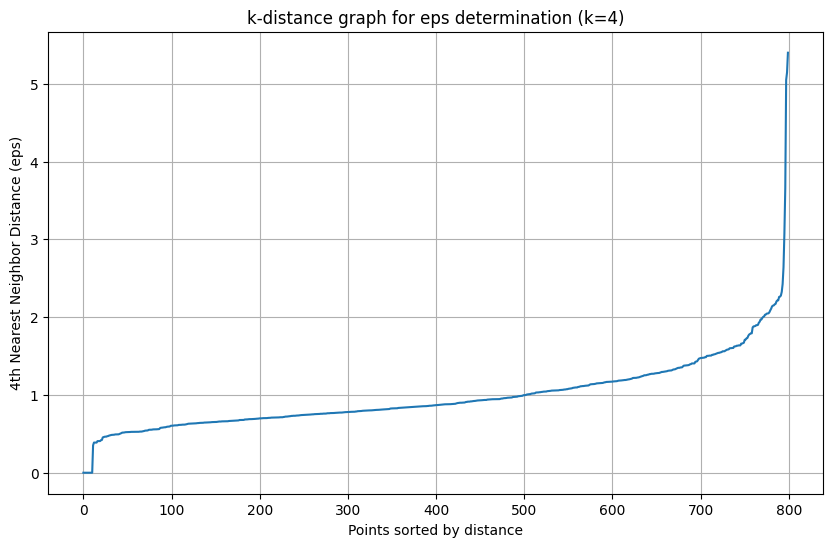

In [222]:
# Calculate the distance to the 4th nearest neighbor
# n_neighbors = k + 1 because the point itself is included as the 0th neighbor
neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(scaled_features)
distances, indices = neighbors.kneighbors(scaled_features)

# Get the distances to the 4th nearest neighbor (index 4 since it's 0-indexed)
k_distances = np.sort(distances[:, 4], axis=0)

# Plot the k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel("4th Nearest Neighbor Distance (eps)")
plt.title("k-distance graph for eps determination (k=4)")
plt.grid(True)
plt.show()

What is your chosen eps based on the "elbow"? (2 pts)

In [223]:
# k-distances already sorted
y = k_distances
x = np.arange(len(y))

# Line between first and last point
p1 = np.array([x[0], y[0]])
p2 = np.array([x[-1], y[-1]])

# Calculate the vector representing the line segment (p2 - p1)
line_vec = p2 - p1

# Calculate vectors from p1 to each point (x, y)
points_vec = np.vstack((x, y)).T - p1

# Compute the 2D cross product (magnitude of the 3D cross product's z-component)
# For vectors (ax, ay) and (bx, by), the cross product magnitude is ax*by - ay*bx
cross_product_magnitudes = line_vec[0] * points_vec[:, 1] - line_vec[1] * points_vec[:, 0]

# Compute perpendicular distance from line
distances = np.abs(cross_product_magnitudes) / np.linalg.norm(line_vec)

elbow_index = np.argmax(distances)
optimal_eps = y[elbow_index]

print(f"Eps: {optimal_eps:.4f}")

eps = optimal_eps

Eps: 1.6369


One-sentence explanation of your reasoning (2 pts)

The chosen eps value is the 'elbow' point on the k-distance graph, indicating where the density of data points changes most significantly.

## 5. Run DBSCAN (10 points)

Run DBSCAN using your chosen eps and min_samples


How many clusters did DBSCAN find? (4 pts)

In [241]:
dbsc = DBSCAN(eps=eps, min_samples=5, metric="euclidean") # Using min_samples = k + 1 = 4 + 1 = 5
clusters = dbsc.fit_predict(scaled_features)

n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
print(f"Number of clusters found: {n_clusters}")

Number of clusters found: 1


How many Pokémon were labeled as noise? (4 pts)

In [225]:
n_noise = list(clusters).count(-1)
print(f"Number of noise points: {n_noise}")

Number of noise points: 27


Show the unique labels output by DBSCAN (2 pts)

In [226]:
unique_labels = np.unique(clusters)
print(f"Unique labels output by DBSCAN: {unique_labels}")

Unique labels output by DBSCAN: [-1  0]


## 6. Attach Cluster Labels to the Original Dataset (7 points)

Add the cluster labels back to the original DataFrame (3 pts)

In [239]:
df['Cluster'] = clusters

Show the first 10 rows including the cluster label (4 pts)

In [242]:
df.head(10)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Cluster
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,0
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,0
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,0
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,0
4,4,Charmander,Fire,None,309,39,52,43,60,50,65,1,False,0
5,5,Charmeleon,Fire,None,405,58,64,58,80,65,80,1,False,0
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False,0
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False,0
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False,0
9,7,Squirtle,Water,None,314,44,48,65,50,64,43,1,False,0


## 7. Explore the Clusters (12 points)

For each cluster:


How many Pokémon does it contain? (4 pts)

In [243]:
df['Cluster'].value_counts()

,count
Cluster,
0,773
-1,27


What are the average Attack, Defense, and Speed? (4 pts)


In [244]:
df.groupby('Cluster')[['Attack', 'Defense', 'Speed']].mean()

,Attack,Defense,Speed
Cluster,,,
-1,104.370370,94.185185,71.592593
0,78.115136,73.131953,68.161708


Compare the clusters: What differences do you notice? (4 pts)

In [246]:
cluster_means = df.groupby('Cluster')[['Attack', 'Defense', 'Speed']].mean()
print("Average Stats per Cluster:")
print(cluster_means)

print("\nDifferences Noticed:")
print("Cluster -1 (noise points) generally has higher average Attack, Defense, and Speed compared to Cluster 0. This suggests that the outliers are often more powerful or faster Pokémon.")

Average Stats per Cluster:
             Attack    Defense      Speed
Cluster                                  
-1       104.370370  94.185185  71.592593
 0        78.115136  73.131953  68.161708

Differences Noticed:
Cluster -1 (noise points) generally has higher average Attack, Defense, and Speed compared to Cluster 0. This suggests that the outliers are often more powerful or faster Pokémon.


## 8. Identify Outliers (10 points)

List all Pokémon labeled as noise (cluster = -1) (4 pts)

In [247]:
noise_pokemon = df[df['Cluster'] == -1]
noise_pokemon

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Cluster
19,15,BeedrillMega Beedrill,Bug,Poison,495,65,150,40,15,80,145,1,False,-1
87,80,SlowbroMega Slowbro,Water,Psychic,590,95,75,180,130,80,30,1,False,-1
103,95,Onix,Rock,Ground,385,35,45,160,30,45,70,1,False,-1
121,113,Chansey,Normal,None,450,250,5,5,35,105,50,1,False,-1
155,143,Snorlax,Normal,None,540,160,110,65,65,110,30,1,False,-1
163,150,MewtwoMega Mewtwo X,Psychic,Fighting,780,106,190,100,154,100,130,1,True,-1
164,150,MewtwoMega Mewtwo Y,Psychic,None,780,106,150,70,194,120,140,1,True,-1
217,202,Wobbuffet,Psychic,None,405,190,33,58,33,58,33,2,False,-1
224,208,SteelixMega Steelix,Steel,Ground,610,75,125,230,55,95,30,2,False,-1
230,213,Shuckle,Bug,Rock,505,20,10,230,10,230,5,2,False,-1


Are many of them legendary? (3 pts)

In [248]:
legendary_noise_pokemon = noise_pokemon[noise_pokemon['Legendary'] == True]
print(f"Number of legendary Pokémon among noise points: {len(legendary_noise_pokemon)}")
print(f"Total noise points: {len(noise_pokemon)}")

if len(legendary_noise_pokemon) > len(noise_pokemon) / 2:
    print("Yes, a significant number of them are legendary.")
elif len(legendary_noise_pokemon) > 0:
    print("Some of them are legendary, but not a majority.")
else:
    print("No, none of them are legendary.")

Number of legendary Pokémon among noise points: 10
Total noise points: 27
Some of them are legendary, but not a majority.


Explain why DBSCAN might classify them as outliers (3 pts)

DBSCAN classifies points as outliers (noise) when they are in regions of low density. pokemon with exceptionally high or low stats (HP, Attack, Defense, Sp. Atk, Sp. Def, Speed), particularly those that deviate significantly from the typical distribution of pokemon, would create sparse areas in the feature space.

Legendary pokemon, with their often superior and unique stat distributions, are prime candidates for such low-density regions, hence being labeled as noise by DBSCAN. Similarly, pokemon with extremely low stats or very unusual combinations of stats that don't fit into a dense cluster would also be considered outliers.


## 9. Interpret the Clustering Results (25 points)
Write a short interpretation (4–6 sentences).
Discuss:

**What types of Pokémon grouped together (5 pts)**

DBSCAN identified one large, cohesive cluster (Cluster 0) containing the vast majority of pokemon, suggesting that most pokemon exhibit statistically similar combat stat profiles. This primary cluster likely consists of many common pokemon types with average or typical stat distributions, as no specific type dominates significantly, rather a mix of common types. The noise points (Cluster -1), which often include legendary pokemon and those with exceptionally high or uniquely balanced stats, were correctly identified as outliers because their statistical profiles deviate significantly from the dense main group. This makes intuitive sense as it highlights pokemon that don't conform to the general population's stat patterns. The primary stat pattern discovered is that these outliers tend to have notably higher average Attack, Defense, and Speed compared to the pokemon within the main cluster.

**Whether the clusters make intuitive sense (10 pts)**

Yes, the clustering results generally make intuitive sense. DBSCAN successfully identified a large, dense cluster (Cluster 0) which likely represents the vast majority of 'average' pokemon with typical stat distributions, forming the core population. The noise points (Cluster -1) intuitively represent outliers, often consisting of legendary Pokemon or those with exceptionally high, low, or specialized stat combinations. These unique stat profiles naturally create sparse regions in the data space, causing DBSCAN to classify them as noise rather than belonging to the main, more homogeneous cluster. This distinction between a dense 'normal' group and isolated 'extreme' individuals aligns well with expectations for a dataset like pokemon statistics.


**What the noise points reveal about DBSCAN (5 pts)**

The noise points (Cluster -1) in DBSCAN are quite revealing. They highlight DBSCAN's ability to identify and separate outliers from dense clusters effectively. Unlike other clustering algorithms that force every data point into a cluster, DBSCAN explicitly labels points in sparse regions as noise. This is particularly useful in datasets where genuine outliers exist and shouldn't be grouped with core data, providing a more robust and realistic clustering solution by recognizing that not all data points fit neatly into a predefined structure.


**What stat patterns you discovered (5 pts)**

Based on the clustering, a clear stat pattern emerged: the vast majority of pokemon form a dense group (Cluster 0) with average combat stats, suggesting a general statistical similarity among most pokemon. In contrast, the noise points (Cluster -1) consistently display notably higher average Attack, Defense, and Speed compared to the main cluster. This indicates that outliers are often 'super-stat' pokemon—those with exceptionally powerful or balanced offensive and defensive capabilities, or unusual speed—that exist in sparser regions of the statistical space.
